#**Importing Libraries**
---

In [14]:
import pandas as pd
import joblib
from imblearn.under_sampling import RandomUnderSampler

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report

import os

#**Data Loading**
---

In [15]:
df = pd.read_csv('../generated_dataset.csv')
display(df.head())
display(df.info())

,Left_End,Right_End,Tile_A,Tile_B,My_Hand_Size,Opp_Hand_Size,Boneyard_Size,Is_Double,Pip_Count,Count_0,...,Count_6,Unplayed_0,Unplayed_1,Unplayed_2,Unplayed_3,Unplayed_4,Unplayed_5,Unplayed_6,Is_Opponent_Vulnerable,Label
0,-1,-1,3,6,7,7,14,0,53,0,...,3,7,6,5,3,6,6,4,0,1
1,-1,-1,3,4,7,7,14,0,53,0,...,3,7,6,5,3,6,6,4,0,0
2,-1,-1,6,6,7,7,14,1,53,0,...,3,7,6,5,3,6,6,4,0,0
3,-1,-1,1,2,7,7,14,0,53,0,...,3,7,6,5,3,6,6,4,0,0
4,-1,-1,2,3,7,7,14,0,53,0,...,3,7,6,5,3,6,6,4,0,0


<class 'pandas.DataFrame'>
RangeIndex: 746595 entries, 0 to 746594
Data columns (total 25 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   Left_End                746595 non-null  int64
 1   Right_End               746595 non-null  int64
 2   Tile_A                  746595 non-null  int64
 3   Tile_B                  746595 non-null  int64
 4   My_Hand_Size            746595 non-null  int64
 5   Opp_Hand_Size           746595 non-null  int64
 6   Boneyard_Size           746595 non-null  int64
 7   Is_Double               746595 non-null  int64
 8   Pip_Count               746595 non-null  int64
 9   Count_0                 746595 non-null  int64
 10  Count_1                 746595 non-null  int64
 11  Count_2                 746595 non-null  int64
 12  Count_3                 746595 non-null  int64
 13  Count_4                 746595 non-null  int64
 14  Count_5                 746595 non-null  int64
 15  Count_6    

None

#**EDA**
---

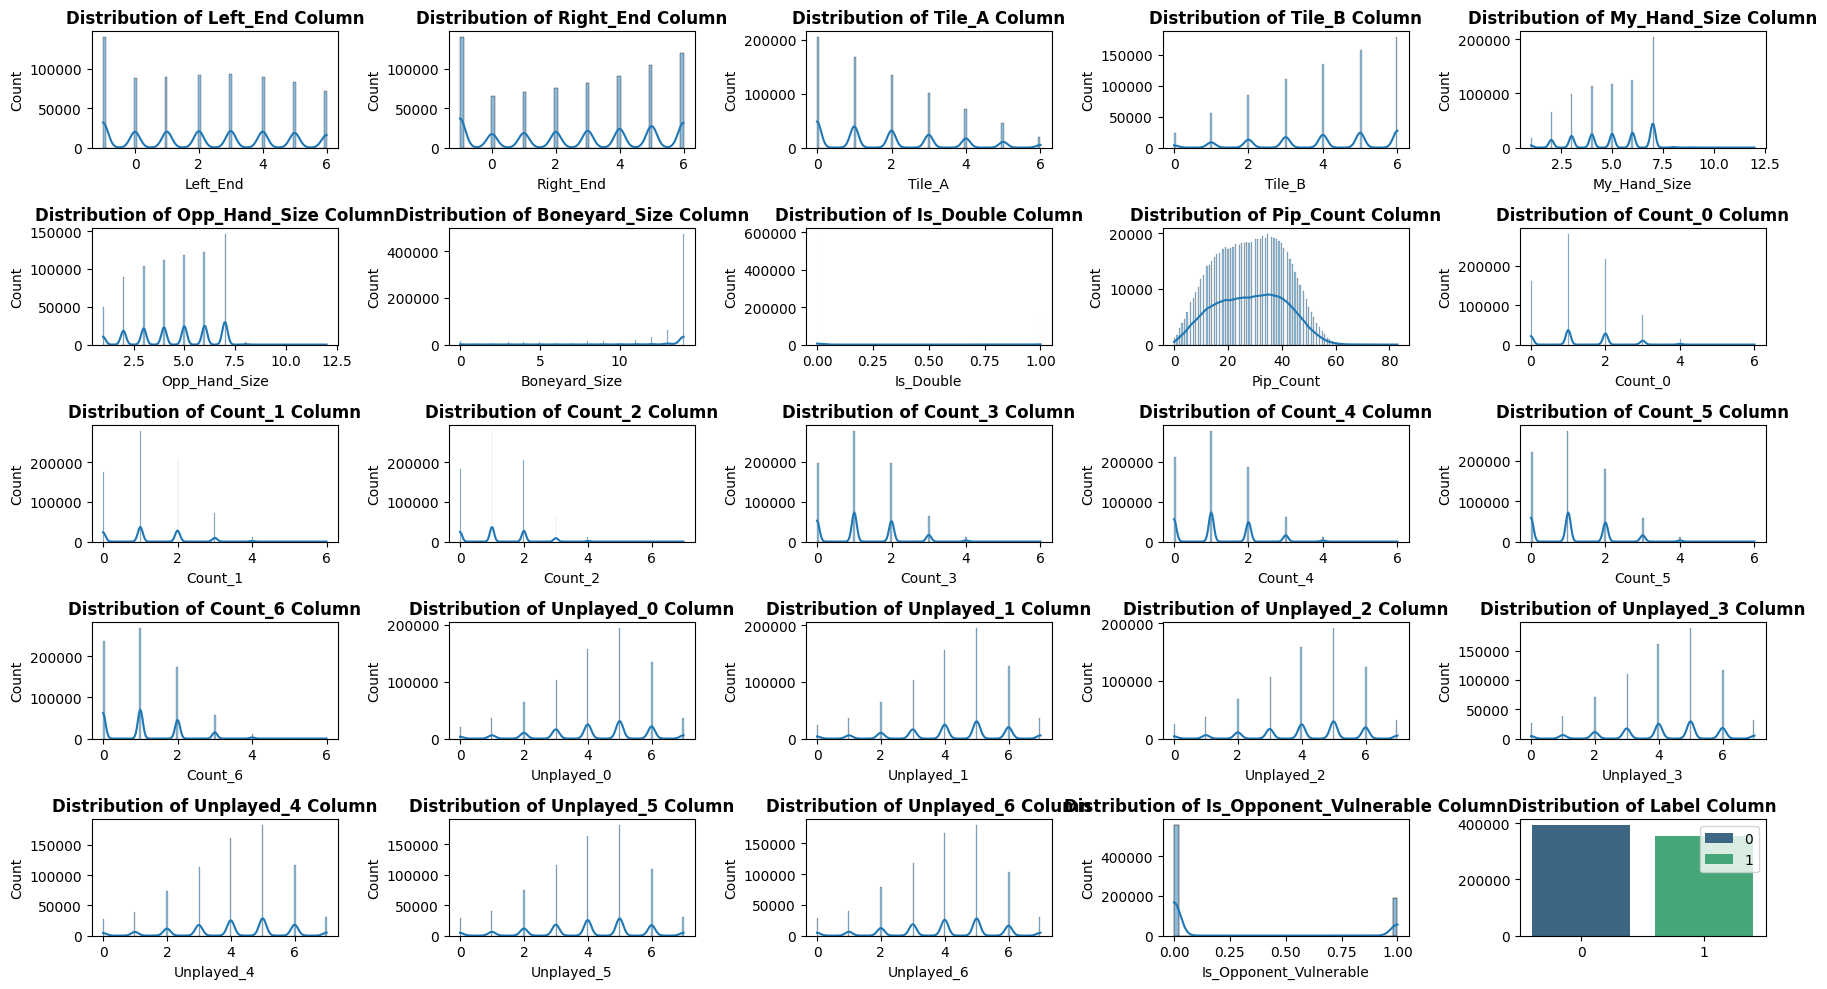

In [16]:
plt.figure(figsize=(18, 10))
for i, col in enumerate(df.columns):
  plt.subplot(5, 5, i+1)
  if col == 'Label':
    counts = df[col].value_counts()
    sns.barplot(x=counts.index.tolist(), y=counts.values.tolist(), hue=counts.index.tolist(), palette='viridis')
  else:
    sns.histplot(df[col], kde=True)
  plt.title(f'Distribution of {col} Column', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

#**Data Preprocessing**
---

In [17]:
x = df[[col for col in df.columns if col != 'Label']]
y = df['Label']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y)

rus = RandomUnderSampler(random_state=42)
x_train, y_train = rus.fit_resample(x_train, y_train)

#**Modelling**
---

In [18]:
rf = RandomForestClassifier(
    n_estimators=400,
    min_samples_split=5,
    min_samples_leaf=4,
    max_features='sqrt',
    max_depth=30,
    bootstrap=True,
    class_weight='balanced',
    random_state=42
)
rf.fit(x_train, y_train)

y_pred = rf.predict(x_test)
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.77      0.78      0.77     77615
           1       0.76      0.74      0.75     71704

    accuracy                           0.76    149319
   macro avg       0.76      0.76      0.76    149319
weighted avg       0.76      0.76      0.76    149319



In [19]:
importances = pd.DataFrame({
    'features': x.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)
importances

,features,importance
8,Pip_Count,0.103851
0,Left_End,0.090328
4,My_Hand_Size,0.089686
1,Right_End,0.084817
3,Tile_B,0.060715
2,Tile_A,0.057084
5,Opp_Hand_Size,0.053463
6,Boneyard_Size,0.035324
21,Unplayed_5,0.031843
22,Unplayed_6,0.031604


In [20]:
joblib.dump(rf, '../models/domino_bot_rf.joblib')

['../models/domino_bot_rf.joblib']